# pyNebulosa: Gene-Weighted Density Estimation for Single-Cell Data

**pyNebulosa** recovers single-cell gene expression signals using kernel density estimation (KDE). In single-cell RNA-seq, technical dropout causes many genes to appear unexpressed in individual cells, making standard feature plots noisy and hard to interpret. pyNebulosa addresses this by smoothing gene expression across a 2D embedding (e.g., UMAP), weighting each cell's contribution by its expression level.

**How it differs from existing tools:**

- **`scanpy.tl.embedding_density`**: Estimates *cell density* in embedding space per category. Does **not** weight by gene expression — only measures how crowded a region is.
- **pyUCell**: Computes *gene signature scores* using rank-based statistics with optional KNN smoothing. A **scoring** tool, not a visualization method.
- **pyNebulosa**: Uses *gene-expression-weighted KDE* to reveal where expressing cells are concentrated, smoothing over dropout noise. A **gene-level visualization** tool.

This tutorial demonstrates pyNebulosa using the PBMC 3K dataset from 10X Genomics.

In [1]:
import matplotlib.pyplot as plt
import scanpy as sc

import pynebulosa as nb

# Load the pre-processed PBMC 3K dataset
adata = sc.datasets.pbmc3k_processed()
print(f"Dataset: {adata.n_obs} cells x {adata.n_vars} genes")
print(f"Cell types: {', '.join(sorted(adata.obs['louvain'].unique()))}")

Dataset: 2638 cells x 1838 genes
Cell types: B cells, CD14+ Monocytes, CD4 T cells, CD8 T cells, Dendritic cells, FCGR3A+ Monocytes, Megakaryocytes, NK cells


## Dataset overview

The PBMC 3K dataset contains 2,638 peripheral blood mononuclear cells sequenced with 10X Genomics. After standard preprocessing (filtering, normalization, HVG selection, PCA, UMAP, clustering), 8 cell types were identified.

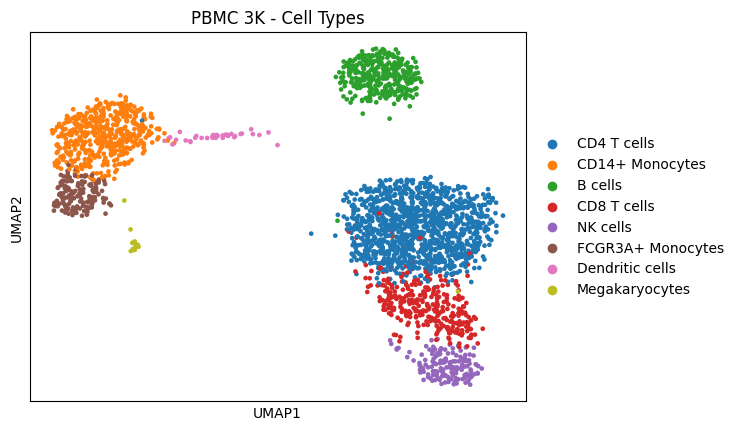

In [2]:
sc.pl.umap(adata, color="louvain", title="PBMC 3K - Cell Types")

## The dropout problem

Standard feature plots (`sc.pl.umap(..., color='gene')`) show raw expression values per cell. Due to technical dropout in scRNA-seq, many truly-expressing cells appear as zeros, creating a noisy, hard-to-interpret visualization.

Let's compare scanpy's standard feature plot with pyNebulosa's density plot for **NKG7**, a natural killer (NK) cell marker.

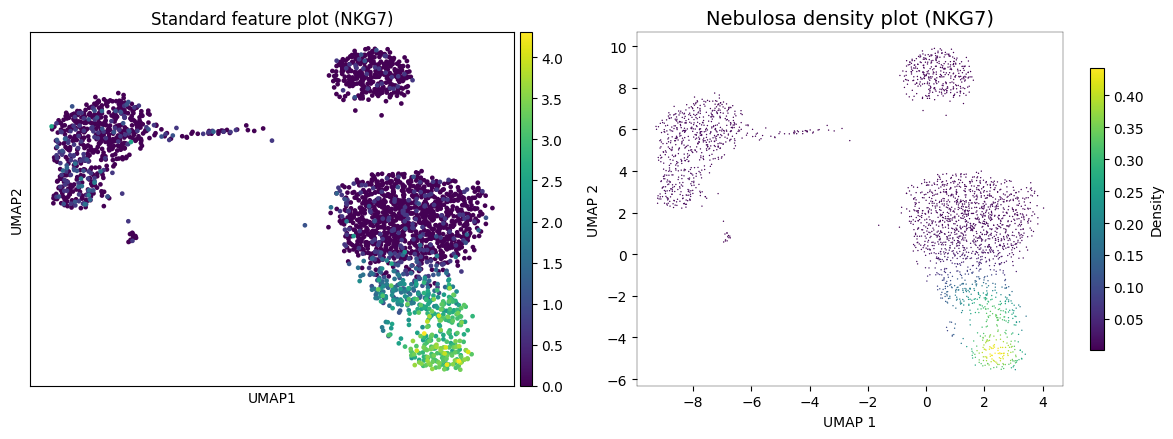

In [3]:
# Side-by-side: standard feature plot vs pyNebulosa density
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Standard scanpy feature plot
sc.pl.umap(adata, color="NKG7", ax=axes[0], show=False, title="Standard feature plot (NKG7)")

# pyNebulosa density plot
nb.plot_density(adata, "NKG7", ax=axes[1])
axes[1].set_title("pyNebulosa density plot (NKG7)", fontsize=14)

fig.tight_layout()
plt.show()

In the standard feature plot (left), NKG7 expression appears scattered with many zero-valued cells obscuring the pattern. pyNebulosa (right) applies gene-weighted kernel density estimation to reveal a smooth density gradient that clearly highlights the NK cell cluster, recovering signal from dropout.

## Visualizing multiple markers

pyNebulosa can plot multiple genes at once, creating a panel for each. Here we visualize canonical markers for four cell types:

- **MS4A1** (CD20): B cells
- **NKG7**: NK cells
- **CST3**: Monocytes and dendritic cells
- **PPBP**: Megakaryocytes

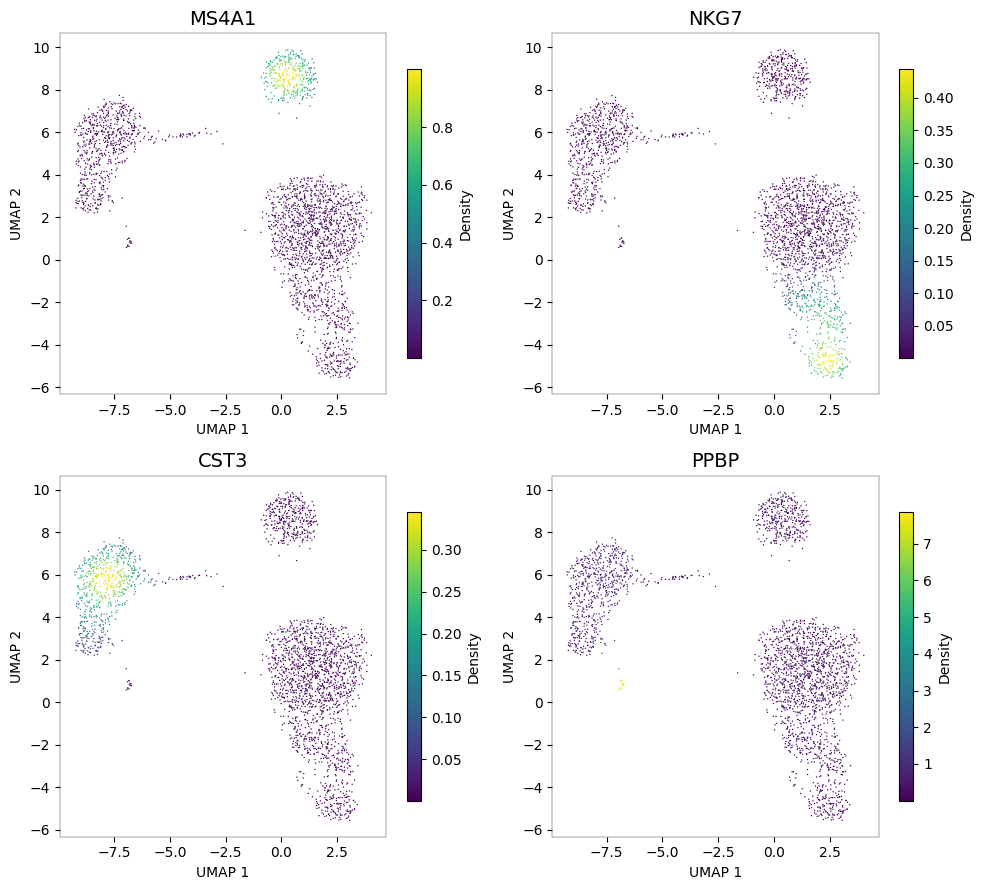

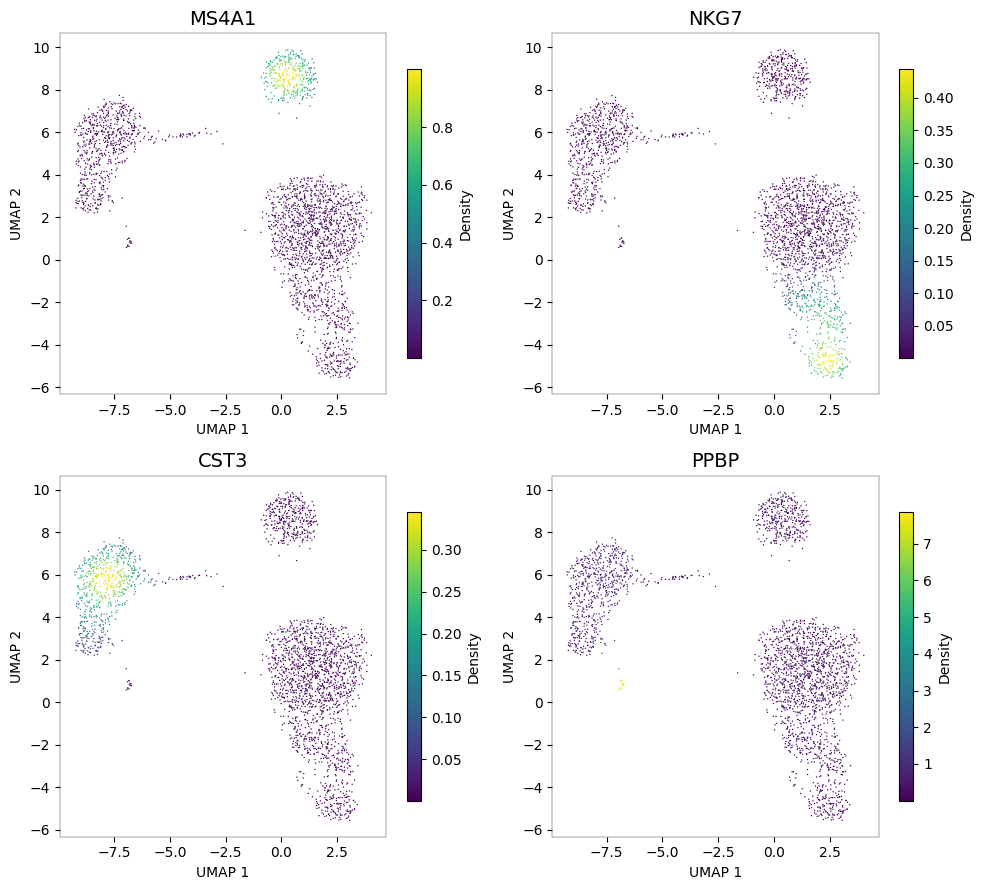

In [4]:
nb.plot_density(adata, ["MS4A1", "NKG7", "CST3", "PPBP"], ncols=2)

Each panel highlights a different cell population. The density-based visualization makes it easy to identify which UMAP regions correspond to which cell types.

## Joint density: identifying cell types by co-expression

When multiple markers define a cell type, pyNebulosa can compute the **joint density** — the product of individual gene densities. This highlights only regions where *all* markers are co-expressed, providing a more specific cell type signal than any single marker alone.

### NK cells: NKG7 + GNLY

Both NKG7 and GNLY (granulysin) are expressed in NK cells. The joint density pinpoints the NK cluster more precisely than either marker alone.

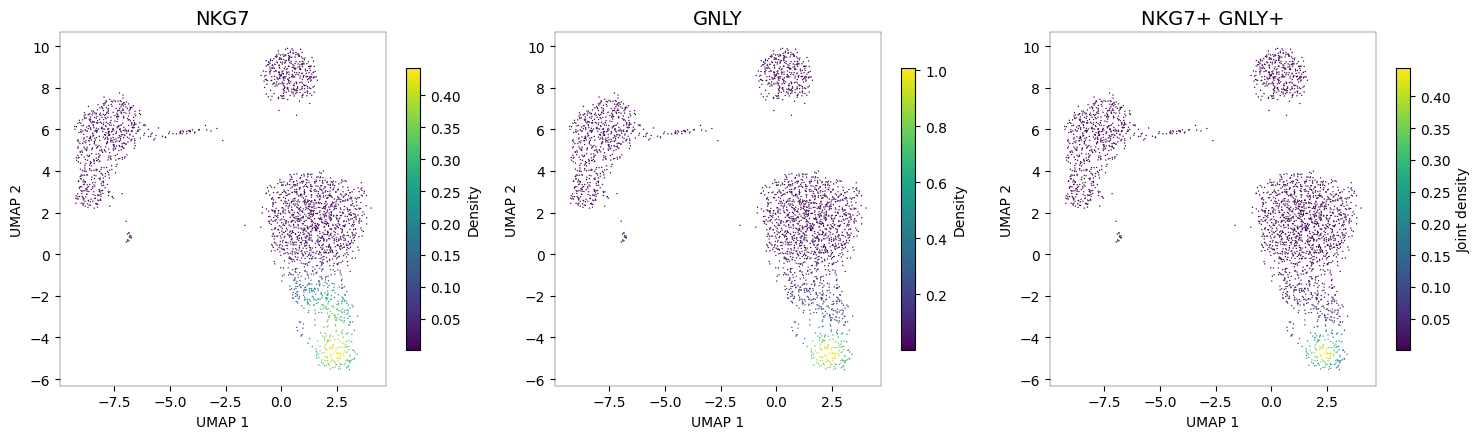

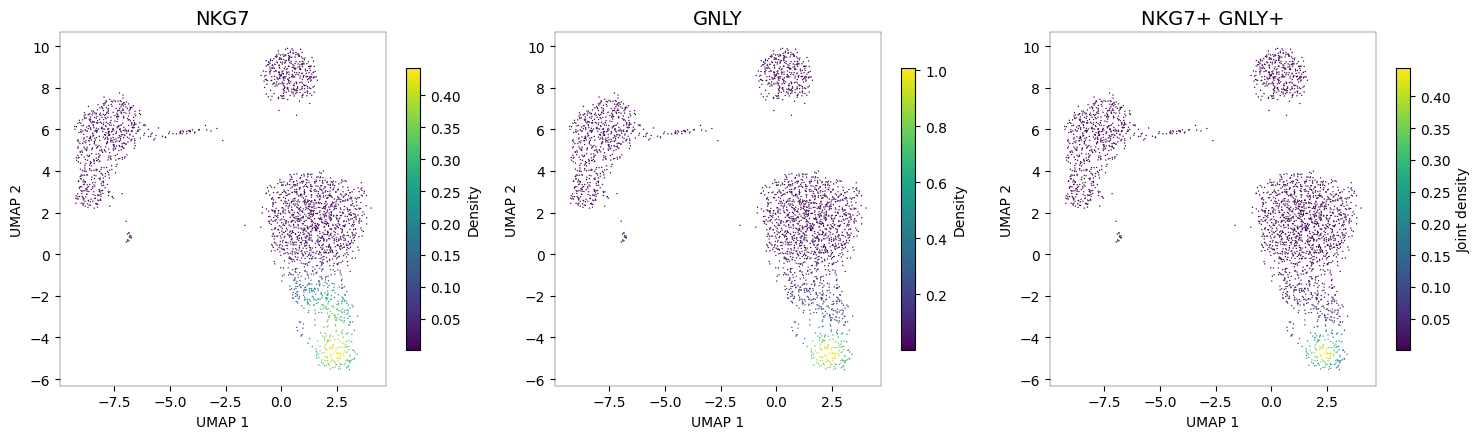

In [5]:
nb.plot_density(adata, ["NKG7", "GNLY"], joint=True)

The third panel (joint density) shows a highly specific signal concentrated in the NK cell cluster, where both NKG7 and GNLY are co-expressed.

### B cells: MS4A1 + CD79A

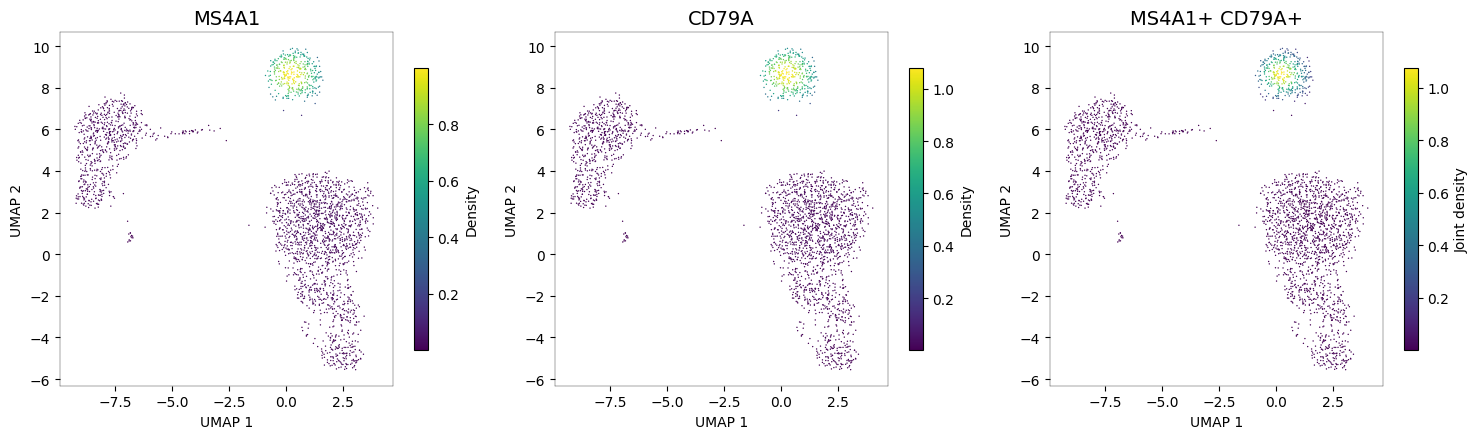

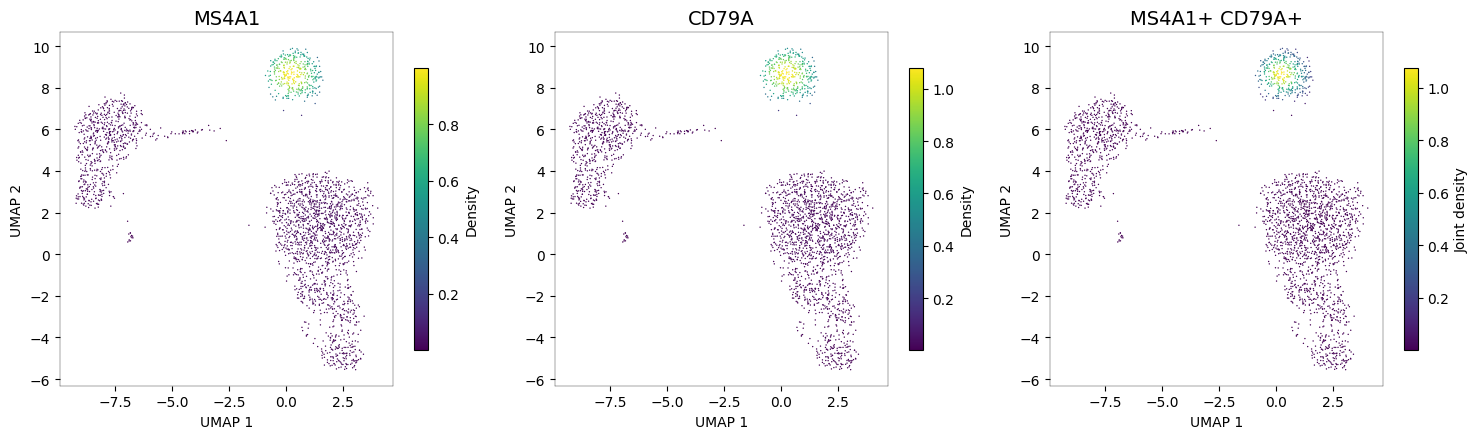

In [6]:
nb.plot_density(adata, ["MS4A1", "CD79A"], joint=True)

### Cytotoxic cells: GZMB + PRF1

Granzyme B (GZMB) and perforin (PRF1) are hallmarks of cytotoxic function, shared between NK cells and CD8+ T cells. The joint density reveals the cytotoxic cell populations.

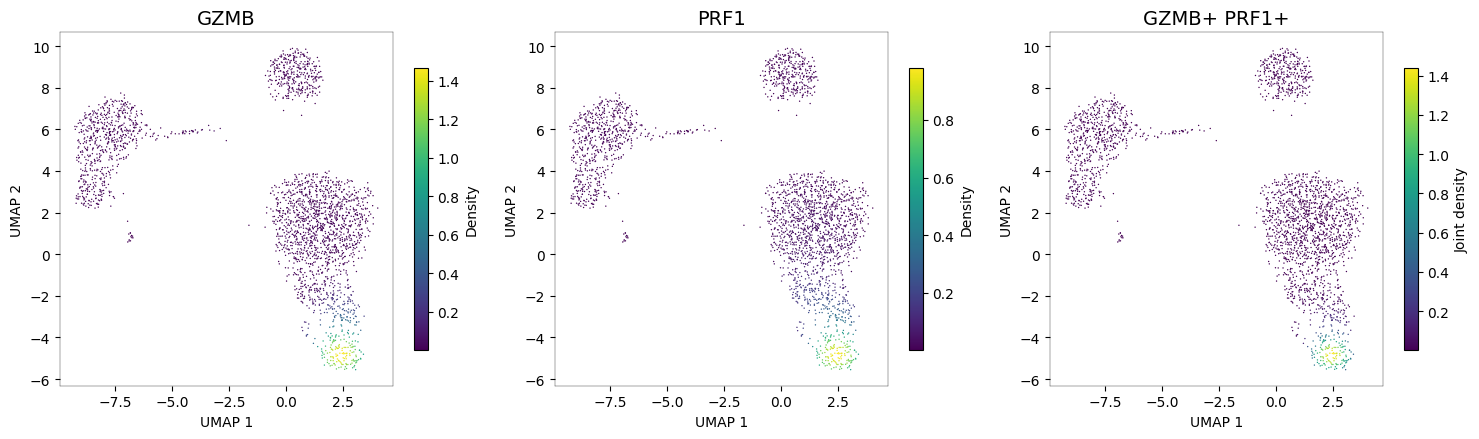

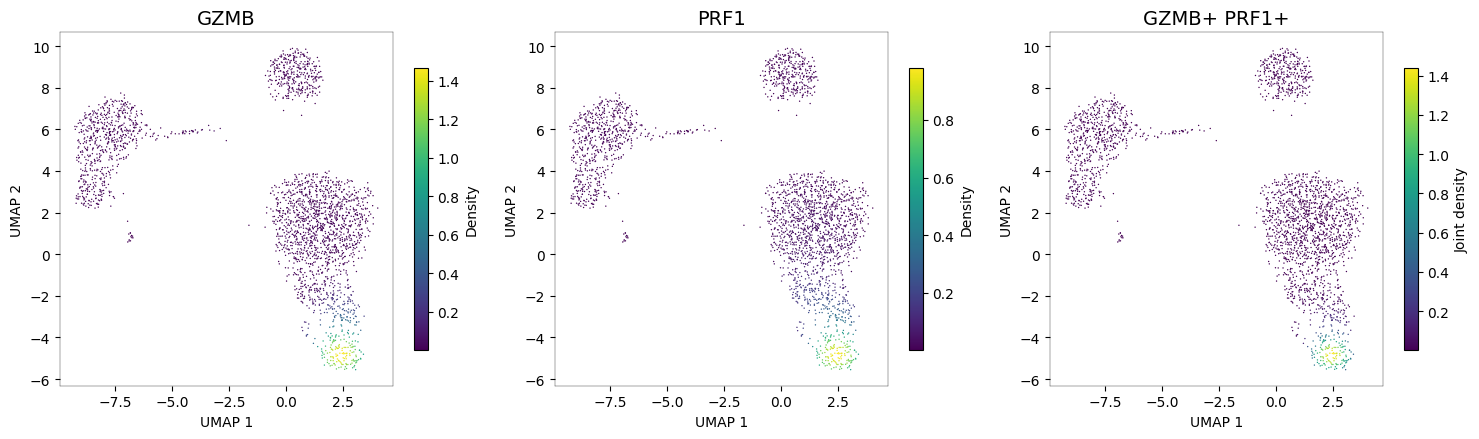

In [7]:
nb.plot_density(adata, ["GZMB", "PRF1"], joint=True)

## Customization

pyNebulosa supports several customization options for fine-tuning your visualizations.

### Color palettes

Any matplotlib colormap can be used via the `cmap` parameter.

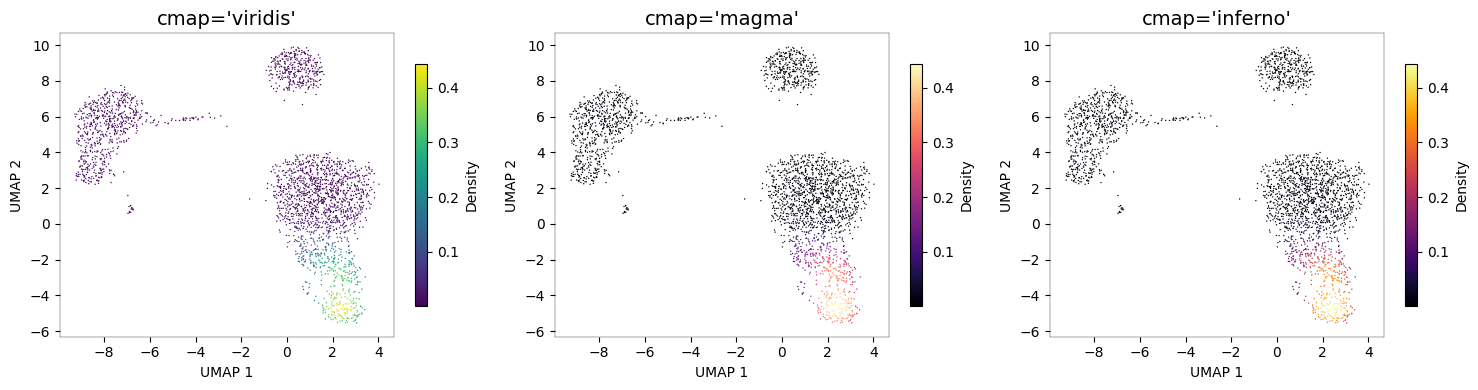

In [8]:
# Compare color palettes
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, cmap in zip(axes, ["viridis", "magma", "inferno"]):
    nb.plot_density(adata, "NKG7", cmap=cmap, ax=ax)
    ax.set_title(f"cmap='{cmap}'", fontsize=14)

fig.tight_layout()
plt.show()

### Bandwidth adjustment

The `adjust` parameter controls smoothing. Lower values preserve more detail; higher values produce smoother density estimates.

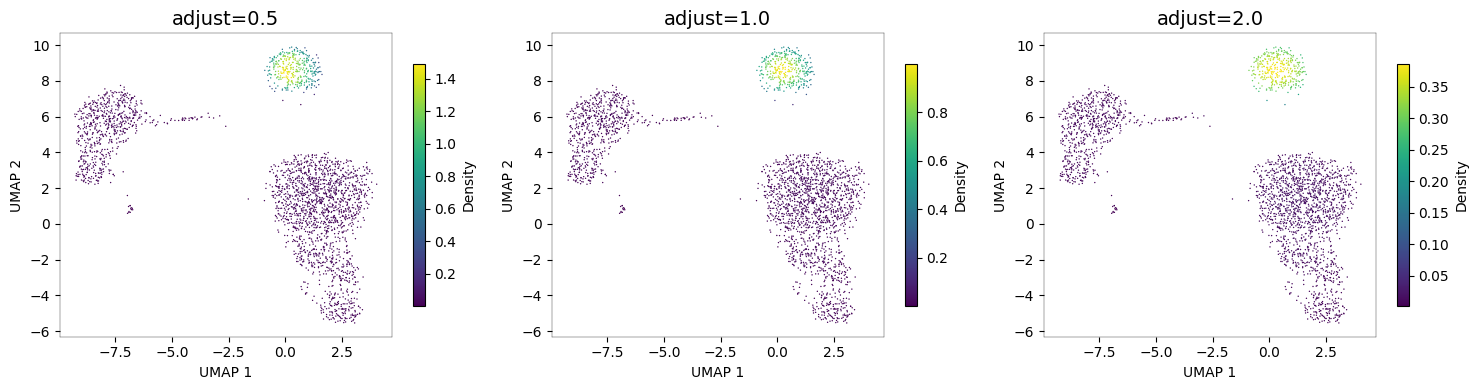

In [9]:
# Compare bandwidth adjustments
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, adj in zip(axes, [0.5, 1.0, 2.0]):
    nb.plot_density(adata, "MS4A1", adjust=adj, ax=ax)
    ax.set_title(f"adjust={adj}", fontsize=14)

fig.tight_layout()
plt.show()

### KDE methods

pyNebulosa supports two KDE methods:
- `"wkde"` (default): Custom weighted 2D KDE with Silverman bandwidth selection
- `"ks"`: scipy's `gaussian_kde` with weighted observations

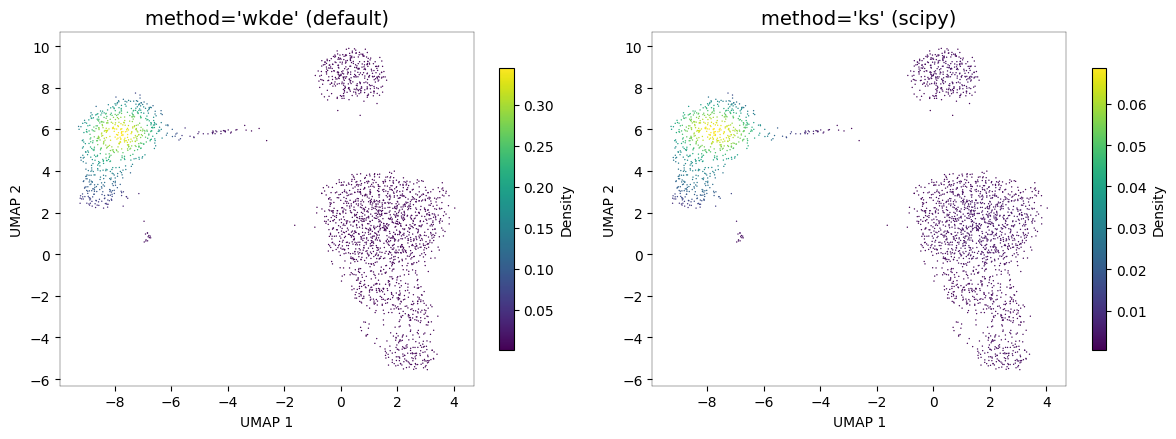

In [10]:
# Compare KDE methods
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

nb.plot_density(adata, "CST3", method="wkde", ax=axes[0])
axes[0].set_title("method='wkde' (default)", fontsize=14)

nb.plot_density(adata, "CST3", method="ks", ax=axes[1])
axes[1].set_title("method='ks' (scipy)", fontsize=14)

fig.tight_layout()
plt.show()

## Programmatic access to density values

For downstream analysis, you can compute density values directly using `calculate_density` and store them in `adata.obs`.

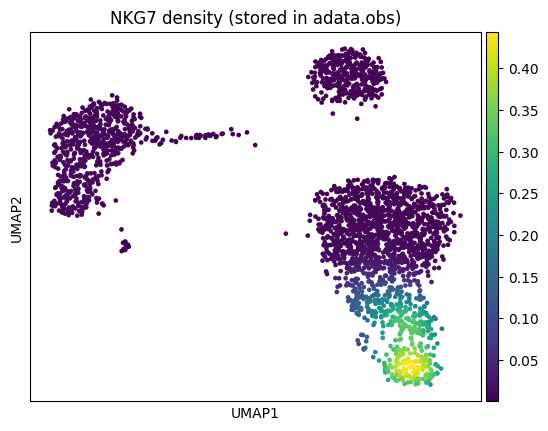

In [11]:
import numpy as np

# Compute density for NKG7 and store in adata.obs
embeddings = adata.obsm["X_umap"]
nkg7_expr = np.asarray(adata[:, "NKG7"].X).flatten()

adata.obs["NKG7_density"] = nb.calculate_density(nkg7_expr, embeddings)

# Now usable with any scanpy plotting function
sc.pl.umap(adata, color="NKG7_density", title="NKG7 density (stored in adata.obs)")

## Saving figures

Plots can be saved directly using the `save` parameter.

In [12]:
# Save a joint density plot to a file
nb.plot_density(
    adata, ["NKG7", "GNLY"], joint=True,
    save="nk_joint_density.png", show=False
)
print("Saved to nk_joint_density.png")

Saved to nk_joint_density.png


## Summary

**pyNebulosa** provides gene-weighted kernel density estimation for single-cell data visualization, filling a gap in the Python/scanpy ecosystem.

**Key functions:**

| Function | Purpose |
|----------|---------|
| `nb.plot_density(adata, features)` | Main visualization function |
| `nb.calculate_density(weights, coords)` | Compute density values programmatically |
| `nb.wkde2d(x, y, w)` | Low-level weighted 2D KDE |

**Key parameters for `plot_density`:**

| Parameter | Description | Default |
|-----------|-------------|---------|
| `joint` | Compute joint density for multiple features | `False` |
| `method` | `"wkde"` or `"ks"` | `"wkde"` |
| `adjust` | Bandwidth adjustment factor | `1.0` |
| `cmap` | Matplotlib colormap | `"viridis"` |
| `reduction` | Key in `adata.obsm` | auto-detect |
| `layer` | Expression data layer | `adata.X` |

**Installation:** `pip install pynebulosa`